In [1]:
import numpy as np
import pandas as pd
from lifelines import WeibullAFTFitter

from pymargins import Margins

rng = np.random.default_rng(5)
n = 1500
df = pd.DataFrame({
    "age": rng.normal(60, 10, n),
    "treated": rng.binomial(1, 0.5, n),
})
lp = 2.0 + 0.5 * df["treated"] - 0.01 * (df["age"] - 60)
T = rng.weibull(1.5, n) * np.exp(lp)
df["duration"] = np.minimum(T, 15)
df["event"] = (T < 15).astype(int)

aft = WeibullAFTFitter().fit(df, duration_col="duration", event_col="event")

In [2]:
from pymargins.adapters import LifelinesWeibullAFTAdapter

_adapter = LifelinesWeibullAFTAdapter(aft, training_data=df)
m = Margins.log_scale(aft, adapter=_adapter, at="overall")
print(m.contrasts(
    scenarios=[
        {"atexog": {"treated": 1}, "label": "treated"},
        {"atexog": {"treated": 0}, "label": "control"},
    ],
    contrasts=[+1, -1],
).summary())

             Margins Result (delta, level=0.95)             
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
treated    1.5237   0.0323  13.0271  0.000    1.4301, 1.6233

n = 1500
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.035
Delta-vs-sim disagreement: 0.026%


In [3]:
print(Margins.linear_scale(aft, adapter=_adapter, at="overall").predict(
    atexog={"treated": [0, 1]}
).summary())

              Margins Result (delta, level=0.95)              
           estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------
treated=0    0.4624   0.0142  32.6223  0.000    0.4346, 0.4901
treated=1    0.7045   0.0118  59.4967  0.000    0.6813, 0.7277

n = 1500
κ: max=0.025
Delta-vs-sim disagreement: 0.399%


In [4]:
print(Margins.linear_scale(aft, adapter=_adapter, at="overall").dydx("age").summary())

           Margins Result (delta, level=0.95)           
     estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------
age   -0.0034   0.0009  -3.7770  0.000  -0.0052, -0.0016

n = 1500
κ: 0.021
Delta-vs-sim disagreement: 4.764%


[Text(0, 0.5, 'Predicted median survival time')]

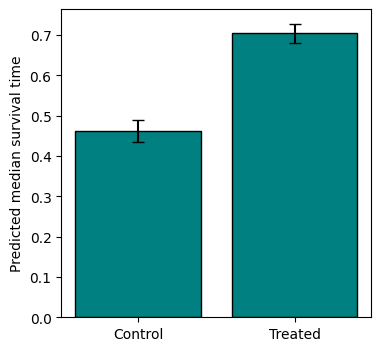

In [5]:
import matplotlib.pyplot as plt

res = Margins.linear_scale(aft, adapter=_adapter, at="overall").predict(
    atexog={"treated": [0, 1]}
)
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["Control", "Treated"], df_plot["estimate"],
       yerr=[df_plot["estimate"] - df_plot["ci_lower"],
             df_plot["ci_upper"] - df_plot["estimate"]],
       capsize=4, color="teal", edgecolor="black")
ax.set(ylabel="Predicted median survival time")